In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, wrapper_hierarchical, WF
import warnings
warnings.simplefilter('ignore', FutureWarning)


# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


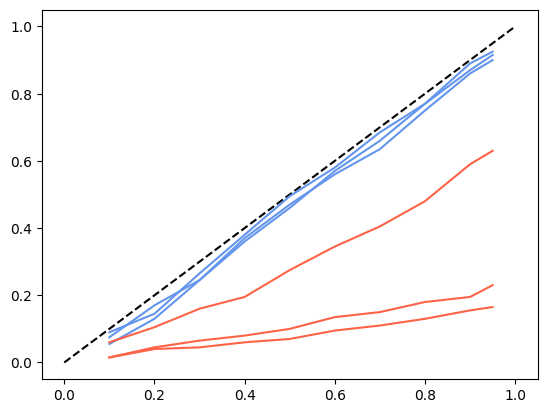

In [15]:
covs = torch.load('covs_bagging.pt').mean(0)
covs_fr = torch.load('covs_fr.pt').mean(0)
conf_levels = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]

plt.plot(np.linspace(0,1,100), np.linspace(0,1,100), color='k', ls='--')
for i in range(3):
    plt.plot(conf_levels, covs[:,i], color='cornflowerblue')
    plt.plot(conf_levels, covs_fr[:,i], color='tomato')

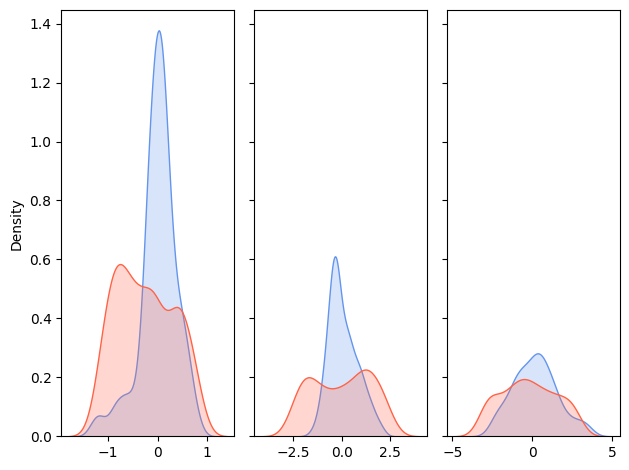

In [16]:
fig, ax = plt.subplots(1,3, tight_layout=True, sharey=True)
accus = torch.load('accus_bagging.pt')
accus_fr = torch.load('accus_fr.pt')

for i in range(3):
    kdeplot(accus[:,i], color='cornflowerblue', fill=True, ax=ax[i])
    kdeplot(accus_fr[:,i], color='tomato', fill=True, ax=ax[i])